# Python Avançado — demonstrações visuais, gráficos e exemplos práticos

Este notebook foi montado para te mostrar **possibilidades mais avançadas** do Python com foco em:
- visualização de dados
- simulações
- análise exploratória
- manipulação de dados
- automação lógica
- exemplos que ficam legais de ver rodando

> Dica: execute célula por célula para aprender melhor.


## 1) Preparando o ambiente

Aqui vamos importar bibliotecas muito usadas em análise e visualização:
- `math` e `random`: cálculos e aleatoriedade
- `statistics`: estatística básica
- `numpy`: matemática numérica
- `pandas`: tabelas e análise de dados
- `matplotlib`: gráficos


In [1]:
import math
import random
import statistics as stats

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configuração visual básica
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

print("Ambiente pronto.")

Ambiente pronto.


## 2) Numpy na prática

O `numpy` é excelente para cálculos rápidos com vetores e matrizes.


In [2]:
numeros = np.arange(1, 11)
quadrados = numeros ** 2
raizes = np.sqrt(numeros)

print("Números:", numeros)
print("Quadrados:", quadrados)
print("Raízes:", np.round(raizes, 2))

Números: [ 1  2  3  4  5  6  7  8  9 10]
Quadrados: [  1   4   9  16  25  36  49  64  81 100]
Raízes: [1.   1.41 1.73 2.   2.24 2.45 2.65 2.83 3.   3.16]


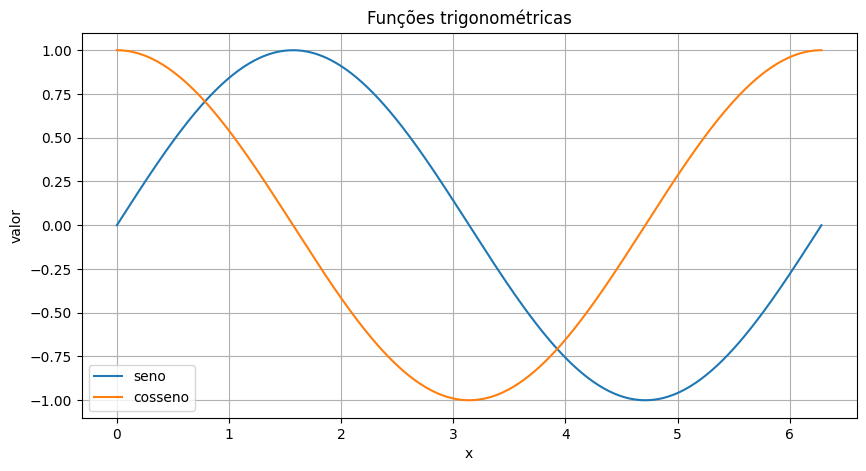

In [3]:
x = np.linspace(0, 2 * np.pi, 400)
y_seno = np.sin(x)
y_cosseno = np.cos(x)

plt.figure()
plt.plot(x, y_seno, label="seno")
plt.plot(x, y_cosseno, label="cosseno")
plt.title("Funções trigonométricas")
plt.xlabel("x")
plt.ylabel("valor")
plt.legend()
plt.show()

## 3) DataFrame com Pandas

O `pandas` é uma das bibliotecas mais úteis do Python.  
Aqui vamos criar um conjunto de dados fictício de vendas.


In [4]:
np.random.seed(42)

produtos = ["Camiseta", "Calça", "Tênis", "Boné", "Jaqueta"]
meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun"]

dados = []
for mes in meses:
    for produto in produtos:
        vendas = np.random.randint(20, 120)
        preco = np.random.randint(50, 250)
        dados.append([mes, produto, vendas, preco, vendas * preco])

df = pd.DataFrame(dados, columns=["Mês", "Produto", "Qtd_Vendida", "Preço", "Faturamento"])
df.head(10)

,Mês,Produto,Qtd_Vendida,Preço,Faturamento
0,Jan,Camiseta,71,142,10082
1,Jan,Calça,34,156,5304
2,Jan,Tênis,91,238,21658
3,Jan,Boné,40,152,6080
4,Jan,Jaqueta,102,124,12648
5,Fev,Camiseta,94,137,12878
6,Fev,Calça,119,153,18207
7,Fev,Tênis,43,180,7740
8,Fev,Boné,41,102,4182
9,Fev,Jaqueta,21,137,2877


In [5]:
resumo_produto = df.groupby("Produto")[["Qtd_Vendida", "Faturamento"]].sum().sort_values("Faturamento", ascending=False)
resumo_produto

,Qtd_Vendida,Faturamento
Produto,,
Calça,417,63163
Jaqueta,343,59622
Camiseta,389,52254
Boné,349,48123
Tênis,367,45378


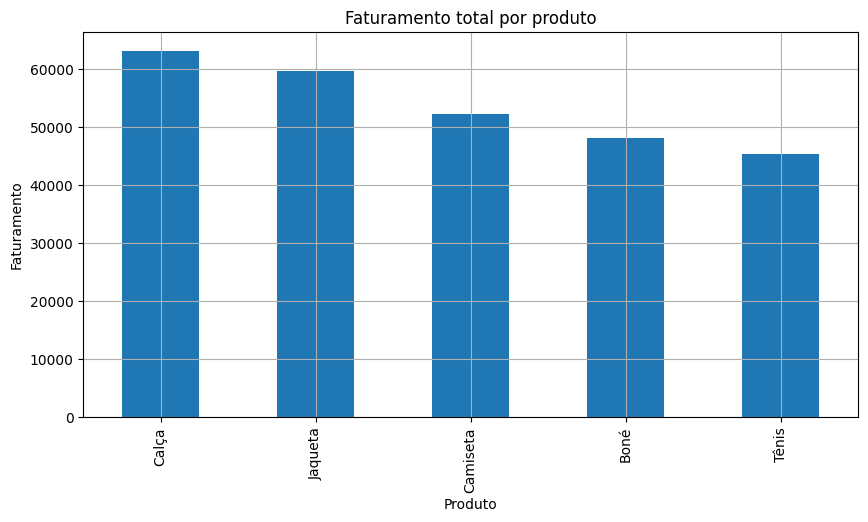

In [6]:
plt.figure()
resumo_produto["Faturamento"].plot(kind="bar")
plt.title("Faturamento total por produto")
plt.xlabel("Produto")
plt.ylabel("Faturamento")
plt.show()

In [7]:
pivot = df.pivot_table(values="Faturamento", index="Mês", columns="Produto", aggfunc="sum")
pivot

Produto,Boné,Calça,Camiseta,Jaqueta,Tênis
Mês,,,,,
Abr,19359,14457,7344,15774,6336
Fev,4182,18207,12878,2877,7740
Jan,6080,5304,10082,12648,21658
Jun,11118,11772,6697,2793,1914
Mai,1820,8362,10990,19872,2200
Mar,5564,5061,4263,5658,5530


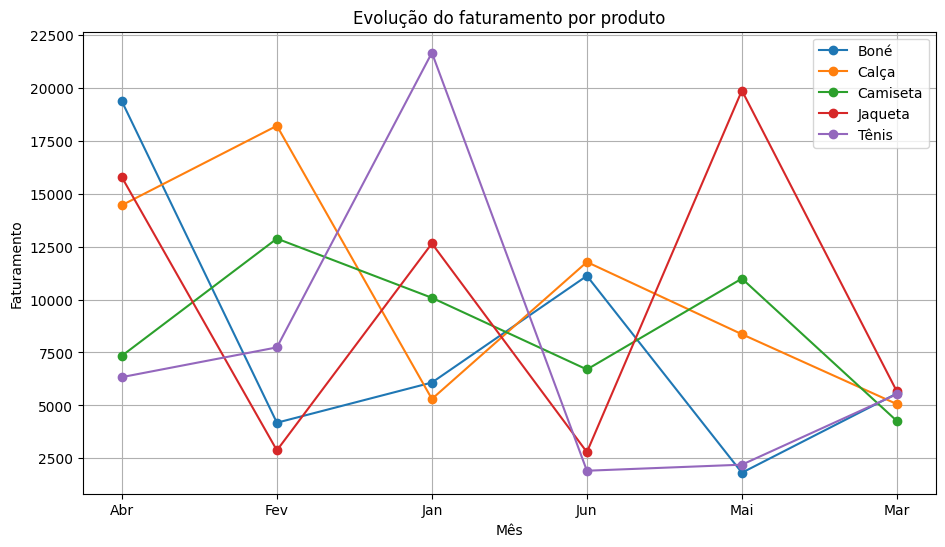

In [8]:
plt.figure(figsize=(11, 6))
for coluna in pivot.columns:
    plt.plot(pivot.index, pivot[coluna], marker="o", label=coluna)

plt.title("Evolução do faturamento por produto")
plt.xlabel("Mês")
plt.ylabel("Faturamento")
plt.legend()
plt.show()

## 4) Heatmap simples com Matplotlib

Mesmo sem bibliotecas extras, dá para fazer visualizações muito boas.


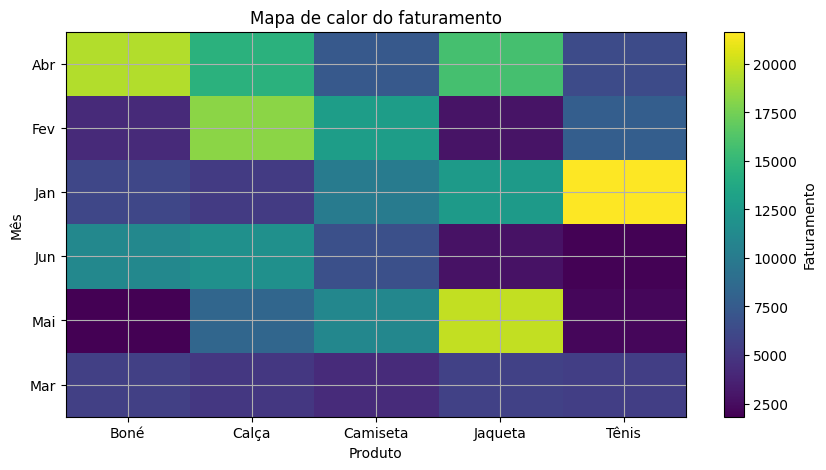

In [9]:
plt.figure(figsize=(10, 5))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="Faturamento")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Mapa de calor do faturamento")
plt.xlabel("Produto")
plt.ylabel("Mês")
plt.show()

## 5) Estatística visual: distribuição de notas

Vamos simular notas de alunos para mostrar histograma e boxplot.


In [10]:
np.random.seed(7)
notas = np.random.normal(loc=7.0, scale=1.5, size=200)
notas = np.clip(notas, 0, 10)

print("Média:", round(float(np.mean(notas)), 2))
print("Mediana:", round(float(np.median(notas)), 2))
print("Desvio padrão:", round(float(np.std(notas)), 2))

Média: 6.95
Mediana: 6.96
Desvio padrão: 1.48


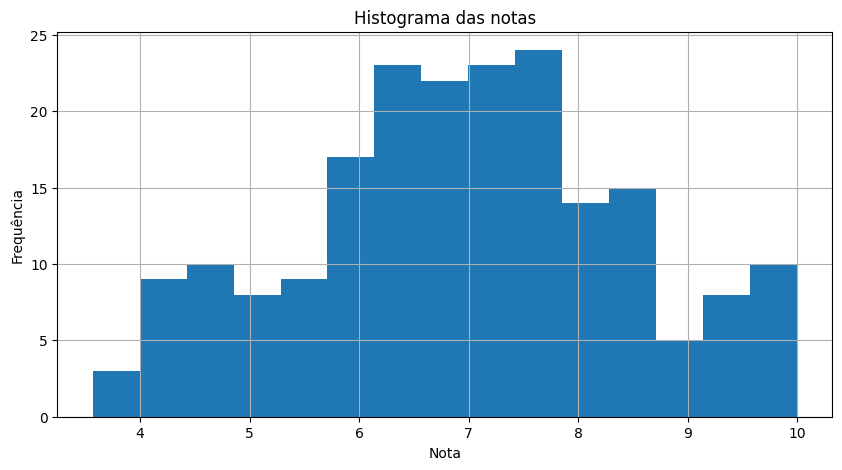

In [11]:
plt.figure()
plt.hist(notas, bins=15)
plt.title("Histograma das notas")
plt.xlabel("Nota")
plt.ylabel("Frequência")
plt.show()

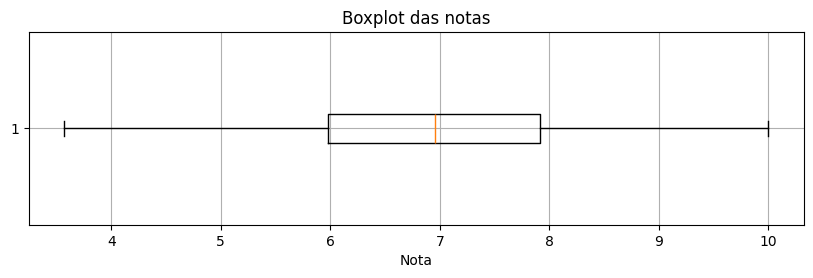

In [12]:
plt.figure(figsize=(10, 2.5))
plt.boxplot(notas, vert=False)
plt.title("Boxplot das notas")
plt.xlabel("Nota")
plt.show()

## 6) Simulação de crescimento com juros compostos

Muito útil para estudos financeiros e cenários.


In [13]:
aporte_inicial = 1000
aporte_mensal = 200
taxa = 0.01  # 1% ao mês
meses = 36

saldo = []
valor = aporte_inicial

for mes in range(1, meses + 1):
    valor = valor * (1 + taxa) + aporte_mensal
    saldo.append(valor)

df_juros = pd.DataFrame({
    "Mês": np.arange(1, meses + 1),
    "Saldo": saldo
})

df_juros.head()

,Mês,Saldo
0,1,1210.000000
1,2,1422.100000
2,3,1636.321000
3,4,1852.684210
4,5,2071.211052


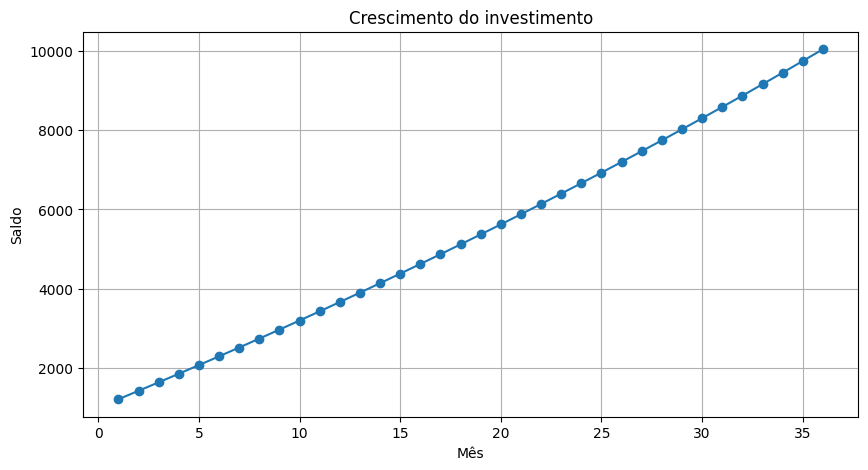

In [14]:
plt.figure()
plt.plot(df_juros["Mês"], df_juros["Saldo"], marker="o")
plt.title("Crescimento do investimento")
plt.xlabel("Mês")
plt.ylabel("Saldo")
plt.show()

## 7) Simulação de fila simples

Exemplo inspirado em problemas de operações: chegadas e atendimentos.


In [15]:
np.random.seed(10)

clientes = 100
tempos_chegada = np.cumsum(np.random.exponential(scale=5, size=clientes))
tempos_atendimento = np.random.exponential(scale=4, size=clientes)

inicio_atendimento = []
fim_atendimento = []
espera = []

fim_anterior = 0

for chegada, atendimento in zip(tempos_chegada, tempos_atendimento):
    inicio = max(chegada, fim_anterior)
    fim = inicio + atendimento
    inicio_atendimento.append(inicio)
    fim_atendimento.append(fim)
    espera.append(inicio - chegada)
    fim_anterior = fim

fila = pd.DataFrame({
    "Chegada": tempos_chegada,
    "Atendimento": tempos_atendimento,
    "Início": inicio_atendimento,
    "Fim": fim_atendimento,
    "Espera": espera
})

fila.head()

,Chegada,Atendimento,Início,Fim,Espera
0,7.377172,3.452293,7.377172,10.829465,0.000000
1,7.482024,7.694780,10.829465,18.524245,3.347442
2,12.502830,0.282107,18.524245,18.806353,6.021415
3,19.410437,2.498448,19.410437,21.908884,0.000000
4,22.861265,6.092107,22.861265,28.953372,0.000000


In [16]:
print("Tempo médio de espera:", round(float(fila["Espera"].mean()), 2))
print("Tempo máximo de espera:", round(float(fila["Espera"].max()), 2))

Tempo médio de espera: 6.72
Tempo máximo de espera: 25.62


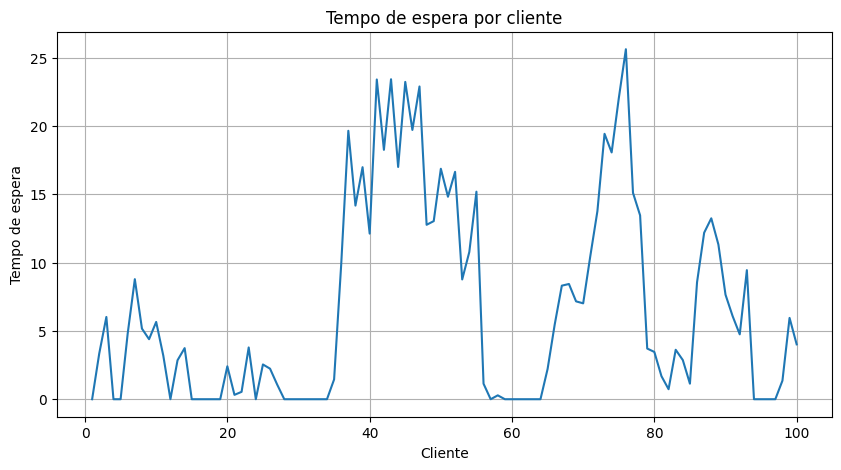

In [17]:
plt.figure()
plt.plot(fila.index + 1, fila["Espera"])
plt.title("Tempo de espera por cliente")
plt.xlabel("Cliente")
plt.ylabel("Tempo de espera")
plt.show()

## 8) Monte Carlo: estimando o valor de π

Exemplo clássico e visual de simulação probabilística.


In [18]:
np.random.seed(123)

n = 5000
x = np.random.uniform(-1, 1, n)
y = np.random.uniform(-1, 1, n)

dentro = x**2 + y**2 <= 1
pi_estimado = 4 * np.mean(dentro)

print("Estimativa de pi:", pi_estimado)
print("Valor real de pi:", math.pi)

Estimativa de pi: 3.1704
Valor real de pi: 3.141592653589793


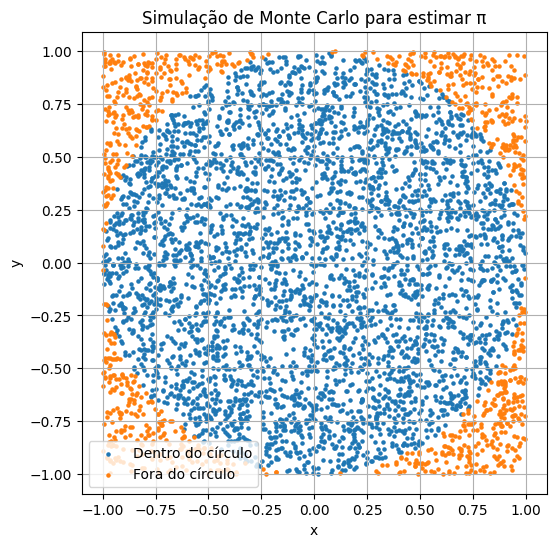

In [19]:
plt.figure(figsize=(6, 6))
plt.scatter(x[dentro], y[dentro], s=5, label="Dentro do círculo")
plt.scatter(x[~dentro], y[~dentro], s=5, label="Fora do círculo")
plt.title("Simulação de Monte Carlo para estimar π")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.axis("equal")
plt.show()

## 9) Correlação entre variáveis

Aqui vamos criar dados fictícios de propaganda e vendas.


In [20]:
np.random.seed(21)

propaganda = np.random.randint(1000, 10000, 50)
vendas = propaganda * 0.08 + np.random.normal(0, 150, 50) + 500

marketing = pd.DataFrame({
    "Propaganda": propaganda,
    "Vendas": vendas
})

marketing.corr(numeric_only=True)

,Propaganda,Vendas
Propaganda,1.000000,0.825776
Vendas,0.825776,1.000000


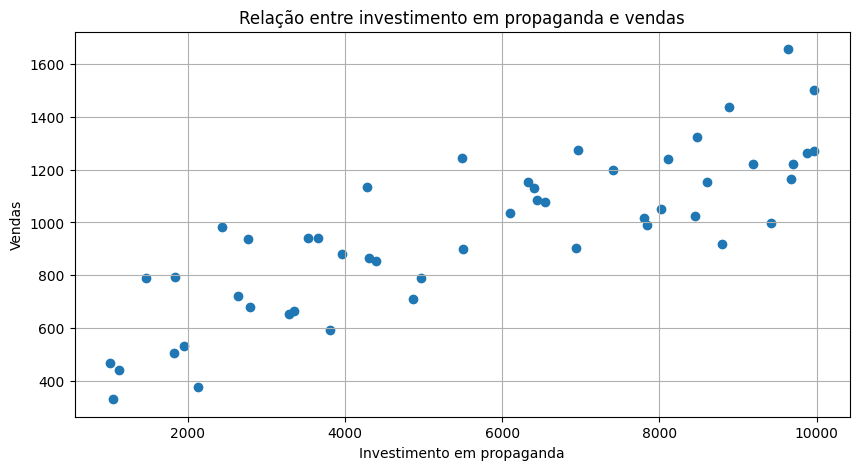

In [21]:
plt.figure()
plt.scatter(marketing["Propaganda"], marketing["Vendas"])
plt.title("Relação entre investimento em propaganda e vendas")
plt.xlabel("Investimento em propaganda")
plt.ylabel("Vendas")
plt.show()

## 10) Regressão linear simples sem biblioteca de ML

Dá para aprender o conceito usando só `numpy`.


In [22]:
coef = np.polyfit(marketing["Propaganda"], marketing["Vendas"], 1)
reta = np.poly1d(coef)

print("Coeficientes da reta:", coef)

Coeficientes da reta: [8.43352488e-02 4.81555871e+02]


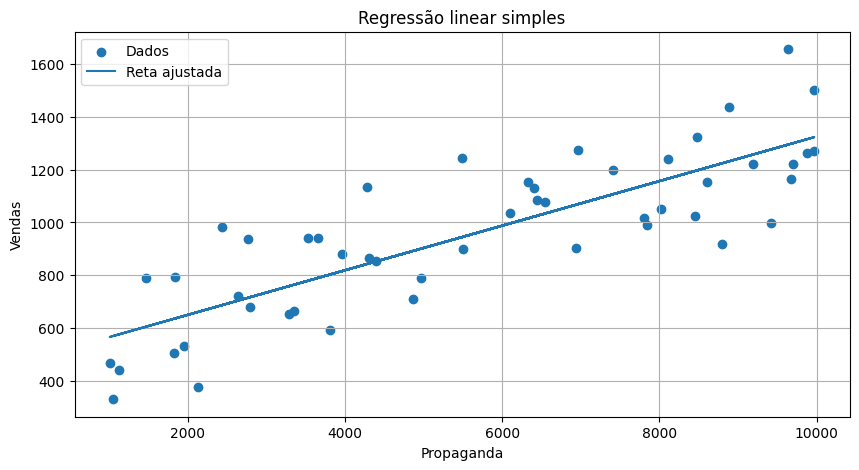

In [23]:
plt.figure()
plt.scatter(marketing["Propaganda"], marketing["Vendas"], label="Dados")
plt.plot(marketing["Propaganda"], reta(marketing["Propaganda"]), label="Reta ajustada")
plt.title("Regressão linear simples")
plt.xlabel("Propaganda")
plt.ylabel("Vendas")
plt.legend()
plt.show()

## 11) Manipulação de strings: análise de texto

Python também é muito forte em texto.


In [24]:
texto = """
Python é uma linguagem poderosa, versátil e muito usada em análise de dados,
automação, inteligência artificial, web, scripts e visualização.
"""

palavras = (
    texto.lower()
    .replace(",", "")
    .replace(".", "")
    .split()
)

frequencia = pd.Series(palavras).value_counts()
frequencia

,count
e,2
é,1
python,1
uma,1
linguagem,1
poderosa,1
versátil,1
muito,1
usada,1
em,1


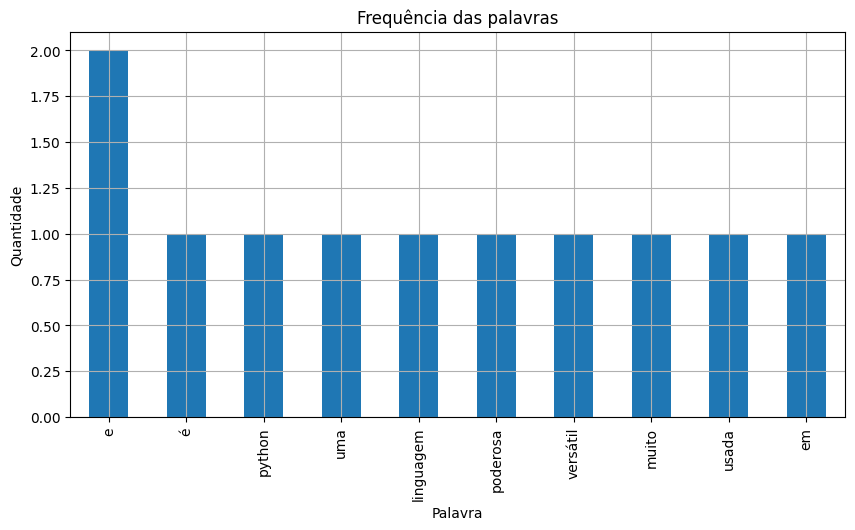

In [25]:
plt.figure()
frequencia.head(10).plot(kind="bar")
plt.title("Frequência das palavras")
plt.xlabel("Palavra")
plt.ylabel("Quantidade")
plt.show()

## 12) Programação orientada a objetos com visualização

Também dá para estruturar sistemas mais organizados.


In [26]:
class Produto:
    def __init__(self, nome, preco, estoque):
        self.nome = nome
        self.preco = preco
        self.estoque = estoque

    def vender(self, quantidade):
        if quantidade <= self.estoque:
            self.estoque -= quantidade
            return quantidade * self.preco
        return 0

    def __repr__(self):
        return f"Produto(nome={self.nome}, preco={self.preco}, estoque={self.estoque})"


catalogo = [
    Produto("Camiseta", 79.90, 40),
    Produto("Calça", 149.90, 25),
    Produto("Tênis", 249.90, 15),
]

for item in catalogo:
    print(item)

Produto(nome=Camiseta, preco=79.9, estoque=40)
Produto(nome=Calça, preco=149.9, estoque=25)
Produto(nome=Tênis, preco=249.9, estoque=15)


In [27]:
faturamentos = {
    produto.nome: produto.vender(np.random.randint(1, 8))
    for produto in catalogo
}

faturamentos

{'Camiseta': 239.70000000000002, 'Calça': 149.9, 'Tênis': 499.8}

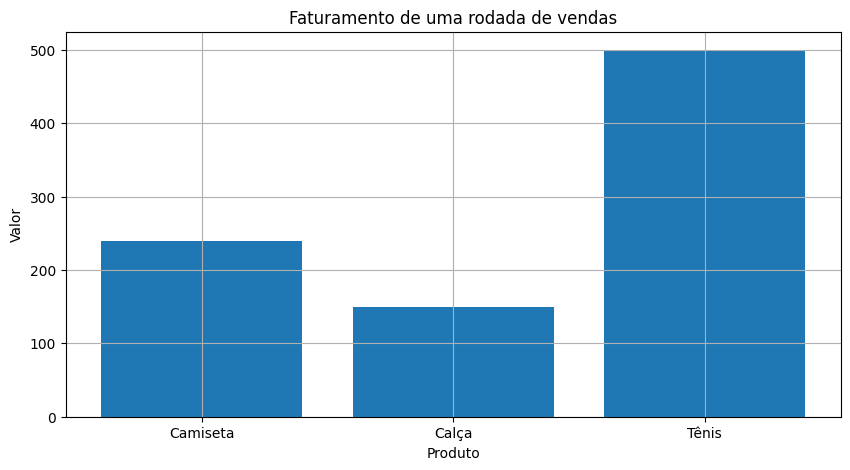

In [28]:
plt.figure()
plt.bar(faturamentos.keys(), faturamentos.values())
plt.title("Faturamento de uma rodada de vendas")
plt.xlabel("Produto")
plt.ylabel("Valor")
plt.show()

## 13) Mini dashboard com vários indicadores

Não é um dashboard interativo web, mas já mostra como consolidar métricas.


In [29]:
indicadores = {
    "Faturamento total": df["Faturamento"].sum(),
    "Ticket médio": df["Faturamento"].sum() / df["Qtd_Vendida"].sum(),
    "Maior venda unitária": df["Preço"].max(),
    "Qtd total vendida": df["Qtd_Vendida"].sum()
}

for nome, valor in indicadores.items():
    print(f"{nome}: {valor:,.2f}")

Faturamento total: 268,540.00
Ticket médio: 143.99
Maior venda unitária: 241.00
Qtd total vendida: 1,865.00


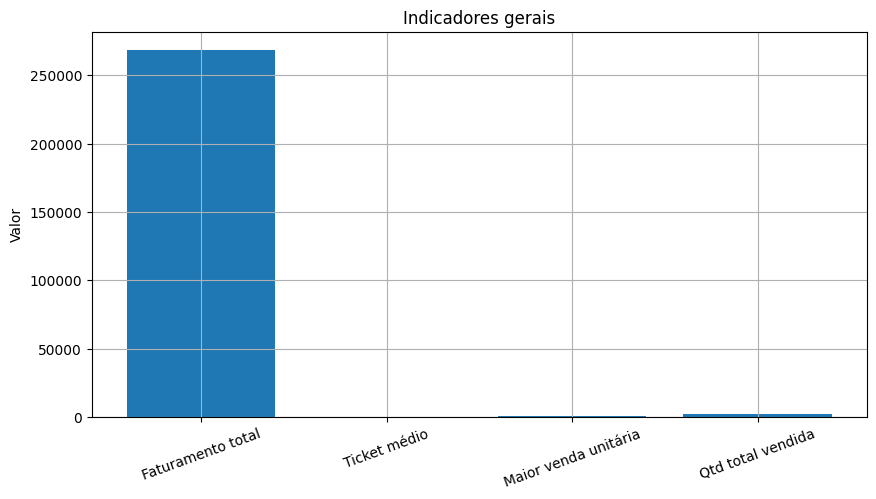

In [30]:
fig, ax = plt.subplots()
nomes = list(indicadores.keys())
valores = list(indicadores.values())

ax.bar(nomes, valores)
ax.set_title("Indicadores gerais")
ax.set_ylabel("Valor")
plt.xticks(rotation=20)
plt.show()

## 14) Animação simples com atualização de gráfico

Exemplo didático: crescimento acumulado ao longo do tempo.


In [31]:
from IPython.display import clear_output, display
import time

acumulado = []
valor = 0

for i in range(1, 21):
    valor += np.random.randint(5, 20)
    acumulado.append(valor)

    plt.figure()
    plt.plot(range(1, len(acumulado) + 1), acumulado, marker="o")
    plt.title("Evolução acumulada (animação simples)")
    plt.xlabel("Passo")
    plt.ylabel("Acumulado")
    plt.show()

    time.sleep(0.2)
    clear_output(wait=True)

print("Animação finalizada.")

Animação finalizada.


## 15) Salvando arquivos

Python também serve para gerar arquivos automaticamente.


In [32]:
resumo_produto.to_csv("resumo_produto.csv")
print("Arquivo salvo: resumo_produto.csv")

Arquivo salvo: resumo_produto.csv


## 16) Desafio final

Tente adaptar este notebook para:
1. usar seus próprios dados
2. criar gráficos com outros indicadores
3. simular metas de vendas
4. montar análises por mês, produto ou loja
5. testar previsões e tendências

---

## Conclusão

Com Python você pode:
- automatizar tarefas
- tratar dados
- criar relatórios
- construir gráficos
- simular cenários
- fazer análise estatística
- iniciar em machine learning
- criar sistemas e ferramentas internas

Esse é o tipo de linguagem que vai desde um script simples até projetos profissionais bem grandes.
